In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import preprocess_image

MODEL_PATH = "../models/coin_classifier.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")
print("Number of classes:", model.output_shape[-1])

Model loaded successfully!
Number of classes: 4


In [2]:
# ============================================================
# STEP 1.5 — LOAD TEST DATA
# ============================================================

import os

TEST_DIR = "../dataset/test"

class_names = sorted([
    class_name
    for class_name in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, class_name))
])

print("Test directory:", TEST_DIR)
print("Classes:", class_names)

# Collect test image paths and labels
test_paths = []
test_labels = []

for label, class_name in enumerate(class_names):

    class_dir = os.path.join(TEST_DIR, class_name)

    for filename in os.listdir(class_dir):

        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):

            test_paths.append(
                os.path.join(class_dir, filename)
            )

            test_labels.append(label)

print("\nTotal test images:", len(test_paths))
print("Class names:", class_names)

Test directory: ../dataset/test
Classes: ['10_rupee', '1_rupee', '2_rupee', '5_rupee']

Total test images: 150
Class names: ['10_rupee', '1_rupee', '2_rupee', '5_rupee']


In [3]:
# ============================================================
# CREATE TEST DATASET USING PREPROCESSING PIPELINE
# ============================================================

import sys
sys.path.append("../src")

from preprocessing import build_dataset

test_dataset = build_dataset(
    test_paths,
    test_labels,
    is_training=False
)

print("Test dataset created successfully!")

Test dataset created successfully!


In [4]:
# ============================================================
# MAKE PREDICTIONS ON TEST DATA
# ============================================================

predictions = model.predict(test_dataset)

# Convert probability output to predicted class
predicted_labels = np.argmax(predictions, axis=1)

# Actual labels
actual_labels = np.array(test_labels)

print("Predictions shape:", predictions.shape)
print("Predicted labels shape:", predicted_labels.shape)
print("Actual labels shape:", actual_labels.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 573ms/step
Predictions shape: (150, 4)
Predicted labels shape: (150,)
Actual labels shape: (150,)


In [5]:
# ============================================================
# TEST ACCURACY
# ============================================================

correct = np.sum(predicted_labels == actual_labels)
total = len(actual_labels)

test_accuracy = correct / total

print("Correct predictions:", correct)
print("Total test images:", total)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Correct predictions: 105
Total test images: 150
Test Accuracy: 0.7000
Test Accuracy: 70.00%


Confusion Matrix:
[[29  0  0  1]
 [ 0 25  0  5]
 [ 0 26  3  1]
 [ 0 12  0 48]]


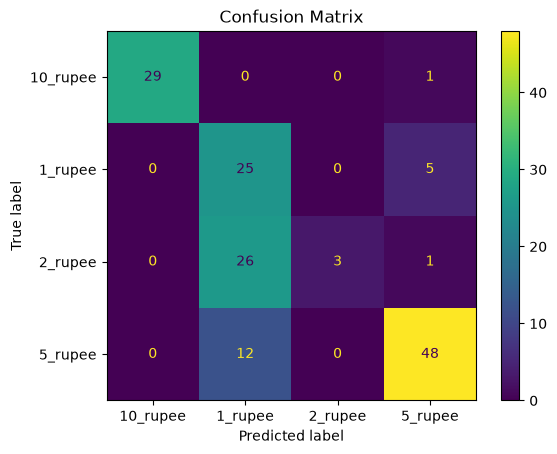

In [7]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(actual_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [8]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    actual_labels,
    predicted_labels,
    target_names=class_names
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

    10_rupee       1.00      0.97      0.98        30
     1_rupee       0.40      0.83      0.54        30
     2_rupee       1.00      0.10      0.18        30
     5_rupee       0.87      0.80      0.83        60

    accuracy                           0.70       150
   macro avg       0.82      0.68      0.63       150
weighted avg       0.83      0.70      0.67       150



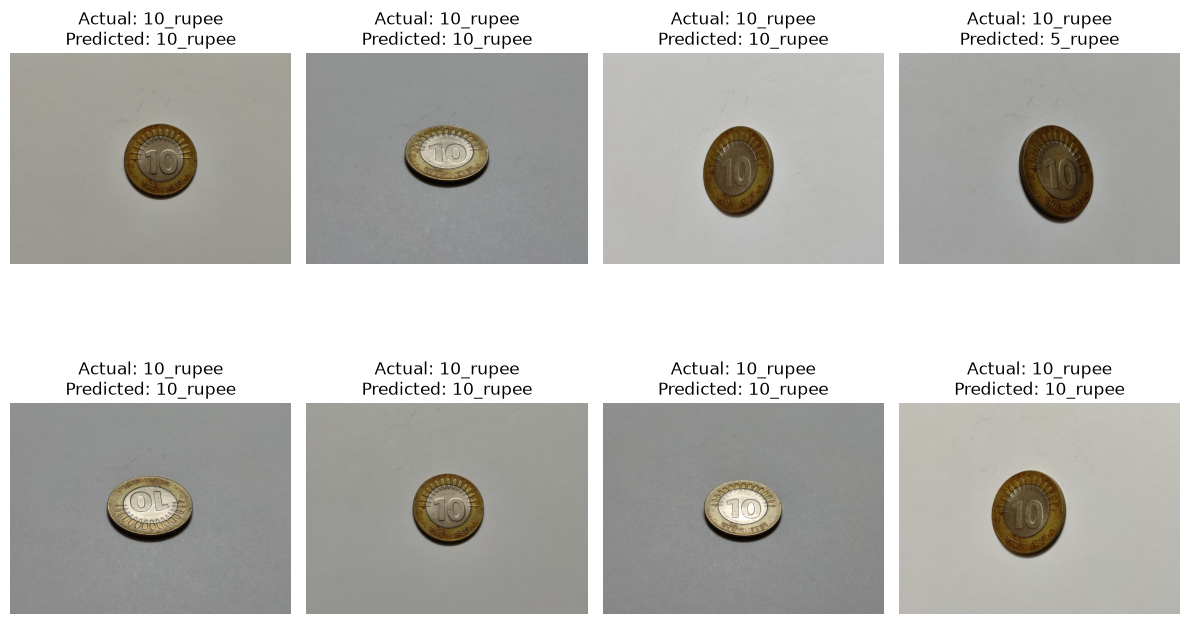

In [11]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

plt.figure(figsize=(12, 8))

# Take first 8 test images
for i in range(8):

    # Load and preprocess image
    image = tf.io.read_file(test_paths[i])
    image = tf.image.decode_jpeg(image, channels=3)

    # Keep original image for display
    display_image = image.numpy()

    # Preprocess using the same pipeline as training
    processed_image, _ = preprocess_image(image, test_labels[i])

    # Model expects a batch
    processed_image = tf.expand_dims(processed_image, axis=0)

    # Prediction
    prediction = model.predict(processed_image, verbose=0)
    predicted_class = np.argmax(prediction[0])

    # Actual class
    actual_class = class_names[test_labels[i]]

    # Predicted class
    predicted_class_name = class_names[predicted_class]

    # Display
    plt.subplot(2, 4, i + 1)
    plt.imshow(display_image)
    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class_name}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()